# QuSpin Analysis Notebook

Select the workspace `.venv` kernel (Python (.venv) HamiltonTrust QuSpin) before running. This notebook runs a small parameter sweep and produces the requested metrics and plots.

In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
print('python exe:', sys.executable)

# imports from the package
from EE_QuSpin_Method.quspin_chain.config import ModelConfig, SweepConfig
from EE_QuSpin_Method.quspin_chain.sweep import run_sweep
from EE_QuSpin_Method.quspin_chain import plotting

python exe: /Users/matthewconway/Documents/GitHub/HamiltonTrust_2026_Spin_Chains/.venv/bin/python


In [9]:
# Sweep configuration (small system for demo). Adjust L/k for larger studies.
L = 6
base_cfg = ModelConfig(L=L, Jxy=1.0, Jz=1.0, Jxy2=0.0, Jz2=0.0, pbc=True)
sweep = SweepConfig(param_name='Jz', param_values=np.linspace(-3.0, 10.0, 50).tolist())
k = 5
sub_sys_A = list(range(L//2))

print('running sweep: L=', L, 'k=', k)
results = run_sweep(base_cfg, sweep, k=k, sub_sys_A=sub_sys_A)
print('done; collected', len(results), 'points')

running sweep: L= 6 k= 5
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!

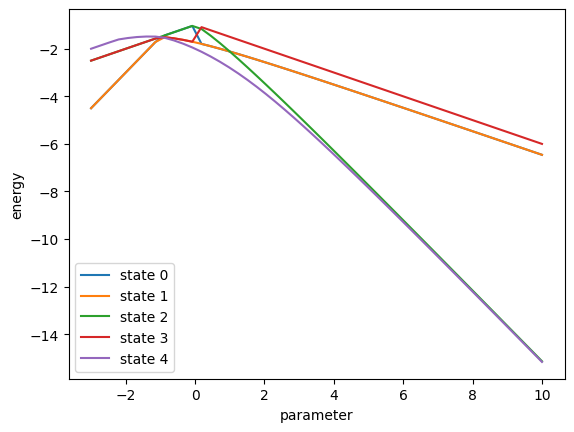

In [10]:
# Energy vs parameter (first 5 states)
fig = plotting.plot_energies_vs_param(results, states=5)
plt.show()

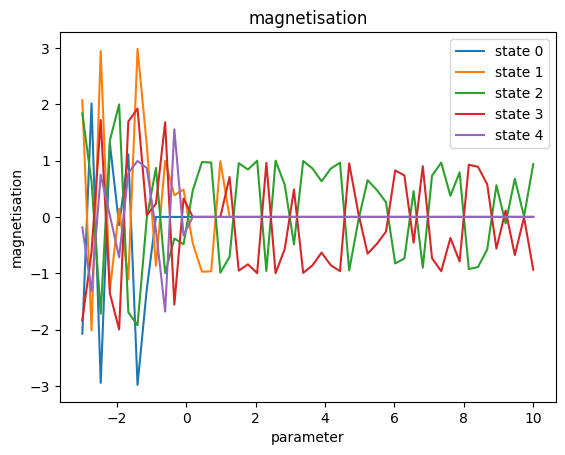

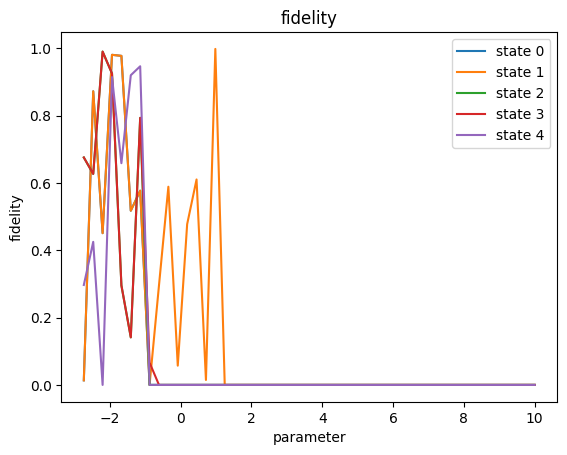

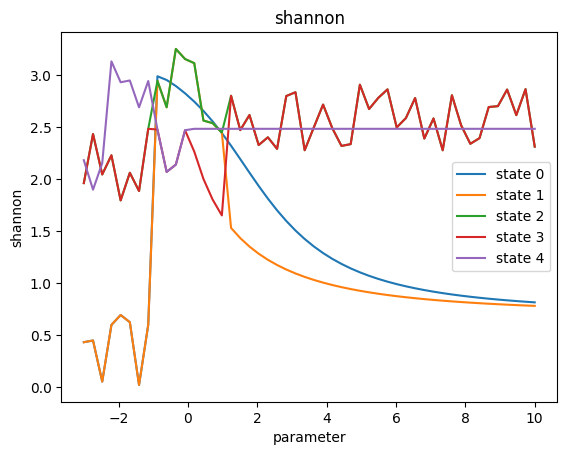

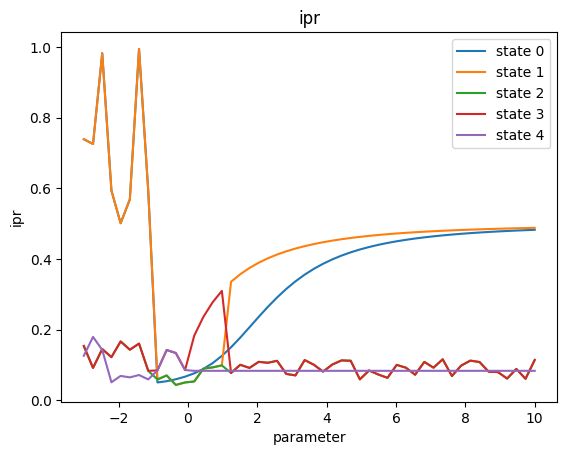

In [11]:
# Plot magnetisation, fidelity, shannon entropy, IPR for tracked states
for key in ['magnetisation', 'fidelity', 'shannon', 'ipr']:
    fig = plotting.plot_observable_vs_param(results, key, states=5)
    plt.title(key)
    plt.show()

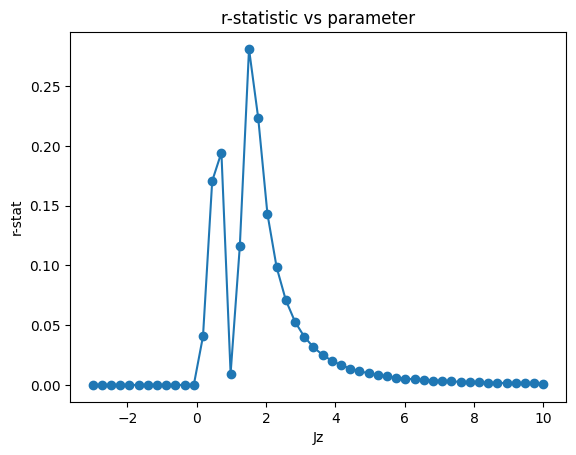

In [12]:
# r-statistic vs parameter (scalar per point)
params = [r['param'] for r in results]
rvals = [r['r_stat'] for r in results]
plt.figure()
plt.plot(params, rvals, '-o')
plt.xlabel(sweep.param_name)
plt.ylabel('r-stat')
plt.title('r-statistic vs parameter')
plt.show()

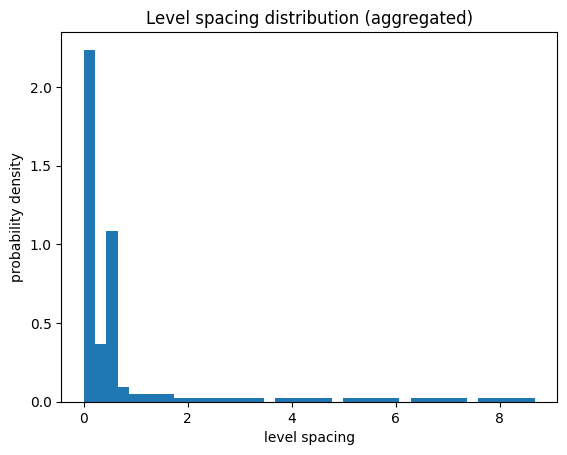

In [13]:
# level spacing distribution (aggregate)
all_ls = np.hstack([r['level_spacings'] for r in results if len(r['level_spacings'])>0])
plt.figure()
plt.hist(all_ls, bins=40, density=True)
plt.xlabel('level spacing')
plt.ylabel('probability density')
plt.title('Level spacing distribution (aggregated)')
plt.show()

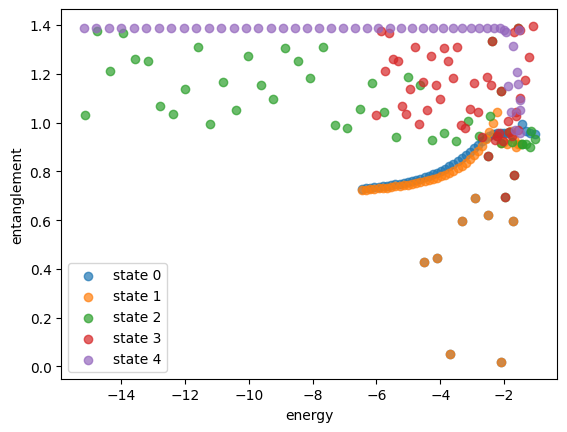

In [14]:
# Entanglement entropy vs energy scatter for tracked states
fig = plotting.plot_entanglement_vs_energy(results, states=5)
plt.show()

## Save figures
You can re-run the plotting cells and save figures manually, or modify the cells above to call `fig.savefig('filename.png')`.